# Exploratory Data Analysis (EDA)

**Project:** N₂O Emissions in Sub-Saharan Africa

---

This notebook documents the exploratory data analysis (EDA) performed prior to feature engineering and machine learning.

# Table of Contents

1. Dataset Overview
2. Data Loading
3. Initial Inspection
4. Data Types
5. Missing Values
6. Duplicate Records
7. Target Variable Analysis
8. Numerical Feature Analysis
9. Categorical Feature Analysis
10. Temporal Analysis
11. Spatial Analysis
12. Outlier Analysis
13. Correlation Analysis
14. Feature Relationships
15. Land Use Comparison
16. Feature Engineering Ideas
17. Key Findings
18. Next Steps


# Librarys

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

## 1. Dataset Overview

Describe the dataset, its origin, scope, and research objective.

## 2. Data Loading

Load the dataset and required libraries.

In [3]:
project_root = Path.cwd().parent
data_path = project_root / "data" / "interim" / "n2o_ssa_landuse_aligned_combined.csv"
df = pd.read_csv(data_path)

## 3. Initial Inspection

Inspect the dataset structure, dimensions, and summary statistics.

In [4]:
n_rows, n_cols = df.shape

print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_cols}")

Number of rows: 5280
Number of columns: 27


In [5]:
df.head()

,Event,Latitude,Longitude,Date/Time,Land use,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),...,VPD day m [kPa] (ERA5 reanalyses),PPPP day m [hPa] (ERA5 reanalyses),SWD day m [W/m**2] (ERA5 reanalyses),PPFD day m [µmol/m**2/s] (ERA5 reanalyses),Duration [days] (Since last precipitation even...),Duration [days] (Since last fertiliser applica...),Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05)),Transformation S (Modeled),Transformation C (Modeled),"N2O flux [µg/m**2/h] (From soil surface, Modeled)"
0,17AG-KILO-FLM,-3.1651,37.2354,2011-03-10,Forest,0,18.030489,23.117343,12.340325,0.067297,...,0.822001,819.566199,50.327010,101.660557,0,0,0.0,0.985770,-0.168101,0.490975
1,17AG-KILO-FLM,-3.1651,37.2354,2011-03-17,Forest,0,17.544443,20.264432,15.170010,8.913426,...,0.262965,818.716753,30.537043,61.684828,0,0,0.0,0.959059,-0.283206,0.000000
2,17AG-KILO-FLM,-3.1651,37.2354,2011-05-07,Forest,0,17.823329,20.757046,15.629188,0.358296,...,0.318645,821.894519,34.651581,69.996192,0,0,0.0,0.394356,-0.918958,-0.457550
3,17AG-KILO-COF,-3.2454,37.3195,2011-05-11,Forest,0,16.740588,19.703080,15.208345,1.130527,...,0.135640,835.511386,27.307722,55.161598,0,0,0.0,0.331418,-0.943484,59.965733
4,17AG-KILO-FOC,-3.1424,37.2423,2011-05-13,Forest,0,16.970899,20.616940,14.695255,0.460711,...,0.245536,816.466490,40.836629,82.489988,0,0,0.0,0.299363,-0.954139,47.169444


In [24]:
with pd.option_context('display.max_columns', 27):
    print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5280 entries, 0 to 5279
Data columns (total 27 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Event                                                          5280 non-null   object 
 1   Latitude                                                       5280 non-null   float64
 2   Longitude                                                      5280 non-null   float64
 3   Date/Time                                                      5280 non-null   object 
 4   Land use                                                       5280 non-null   object 
 5   Fert N [kg/ha] (Recorded at time of application)               5280 non-null   int64  
 6   TTT day m [°C] (ERA5 reanalyses)                               5280 non-null   float64
 7   TxTxTx day max [°C] (ERA5 reanalyses)                       

| Feature                               | Description                                                             | Unit      | Source                                                |
| ------------------------------------- | ------------------------------------------------------------------------ | ------------ | ----------------------------------------------------- |
| Event                                 | Identifier of the measurement campaign or observation event.             | -            | Original dataset                                      |
| Latitude                              | Geographic latitude of the measurement site.                             | °            | Original dataset                                      |
| Longitude                             | Geographic longitude of the measurement site.                            | °            | Original dataset                                      |
| Date/Time                             | Date of the observation.                                                 | Date         | Original dataset                                      |
| Land use                              | Land use category (e.g., Cropland, Forest, Grassland).                   | -            | Original dataset                                      |
| Fert N                                | Nitrogen fertilizer applied at the measurement site.                     | kg/ha        | Original dataset                                      |
| TTT day m                             | Daily mean 2 m air temperature.                                          | °C           | ERA5 ([Climate Data Store][1])                        |
| TxTxTx day max                        | Daily maximum 2 m air temperature.                                       | °C           | ERA5 ([Climate Data Store][1])                        |
| TnTnTn day min                        | Daily minimum 2 m air temperature.                                       | °C           | ERA5 ([Climate Data Store][1])                        |
| Precip day total                      | Daily accumulated precipitation.                                         | mm/day       | ERA5 ([Climate Data Store][1])                        |
| Soil moisture (0–7 cm)                | Volumetric water content in the upper soil layer.                        | m³/m³        | ERA5-Land ([Climate Data Store][1])                   |
| Soil moisture                         | Volumetric soil moisture of deeper layers.                               | m³/m³        | ERA5-Land ([Climate Data Store][1])                   |
| T soil                                | Mean soil temperature.                                                   | °C           | ERA5-Land ([Climate Data Store][1])                   |
| Cloud cov                             | Fractional cloud cover.                                                  | %            | ERA5 ([era5cli.readthedocs.io][2])                    |
| VPD                                   | Vapour Pressure Deficit. Indicator of atmospheric dryness.               | kPa          | AgERA5 / ERA5 ([Climate Data Store][3])               |
| PPPP day m                            | Mean surface atmospheric pressure.                                       | hPa          | ERA5 ([Climate Data Store][1])                        |
| SWD                                   | Surface downward shortwave radiation.                                    | W/m²         | ERA5 ([Climate Data Store][1])                        |
| PPFD                                  | Photosynthetic Photon Flux Density (available light for photosynthesis). | µmol m⁻² s⁻¹ | Derived from ERA5 radiation ([Climate Data Store][3]) |
| Duration since precipitation          | Number of days since the last precipitation event.                       | days         | Derived feature                                       |
| Duration since fertiliser application | Days since nitrogen fertilizer application.                              | days         | Derived feature                                       |
| Fert N dec adj exp                    | Fertilizer amount after exponential decay adjustment (k = 0.05).         | kg/ha        | Original study                                        |
| Transformation S                      | Model-derived sulfur transformation variable.                            | -            | Original N₂O model                                    |
| Transformation C                      | Model-derived carbon transformation variable.                            | -            | Original N₂O model                                    |
| N₂O flux                              | Target variable: modeled nitrous oxide emission from the soil surface.   | µg m⁻² h⁻¹   | Original study                                        |

[1]: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-complete?tab=overview&utm_source=chatgpt.com "Complete ERA5 global atmospheric reanalysis"
[2]: https://era5cli.readthedocs.io/en/stable/reference/variables/?utm_source=chatgpt.com "Variable overview - era5cli documentation"
[3]: https://cds.climate.copernicus.eu/datasets/sis-agrometeorological-indicators-timeseries?tab=overview&utm_source=chatgpt.com "Agrometeorological indicators time-series from 1979 to present derived from reanalysis"



Features that require more research:
- Transformation S (Modeled)
- Transformation C (Modeled)
- Fert N dec adj exp

## 5. Missing Values

Analyze missing values, their distribution, and potential handling strategies.

In [38]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame(name="missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary = missing_summary.sort_values(
    by="missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
Event,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Date/Time,0,0.0
Land use,0,0.0
Fert N [kg/ha] (Recorded at time of application),0,0.0
TTT day m [°C] (ERA5 reanalyses),0,0.0
TxTxTx day max [°C] (ERA5 reanalyses),0,0.0
TnTnTn day min [°C] (ERA5 reanalyses),0,0.0
Precip day total [mm/day] (ERA5 reanalyses),0,0.0


## 6. Duplicate Records

Check for duplicate observations and evaluate whether they should be removed.

In [23]:
duplicated_columns = df.columns[df.columns.duplicated()].tolist()

if duplicated_columns:
    print("Duplicated column names found:")
    print(duplicated_columns)
else:
    print("No duplicated column names found.")

No duplicated column names found.


## 7. Target Variable Analysis

Investigate the distribution, range, skewness, and summary statistics of the target variable.

In [39]:
TARGET_COLUMN = "N2O flux [µg/m**2/h] (From soil surface, Modeled)"

df[TARGET_COLUMN].describe()

count    5280.000000
mean       12.095709
std        20.839097
min       -21.149615
25%         1.896372
50%         5.142646
75%        13.045997
max       242.346036
Name: N2O flux [µg/m**2/h] (From soil surface, Modeled), dtype: float64

In [43]:
print(f"Minimum N2O flux: {df[TARGET_COLUMN].min():.4f}")
print(f"Maximum N2O flux: {df[TARGET_COLUMN].max():.4f}")
print(f"Mean N2O flux: {df[TARGET_COLUMN].mean():.4f}")
print(f"Median N2O flux: {df[TARGET_COLUMN].median():.4f}")
print(f"Standard deviation: {df[TARGET_COLUMN].std():.4f}")

Minimum N2O flux: -21.1496
Maximum N2O flux: 242.3460
Mean N2O flux: 12.0957
Median N2O flux: 5.1426
Standard deviation: 20.8391


In [44]:
print(f"Minimum N2O flux: {df[TARGET_COLUMN].min():.4f}")
print(f"Maximum N2O flux: {df[TARGET_COLUMN].max():.4f}")
print(f"Mean N2O flux: {df[TARGET_COLUMN].mean():.4f}")
print(f"Median N2O flux: {df[TARGET_COLUMN].median():.4f}")
print(f"Standard deviation: {df[TARGET_COLUMN].std():.4f}")

Minimum N2O flux: -21.1496
Maximum N2O flux: 242.3460
Mean N2O flux: 12.0957
Median N2O flux: 5.1426
Standard deviation: 20.8391


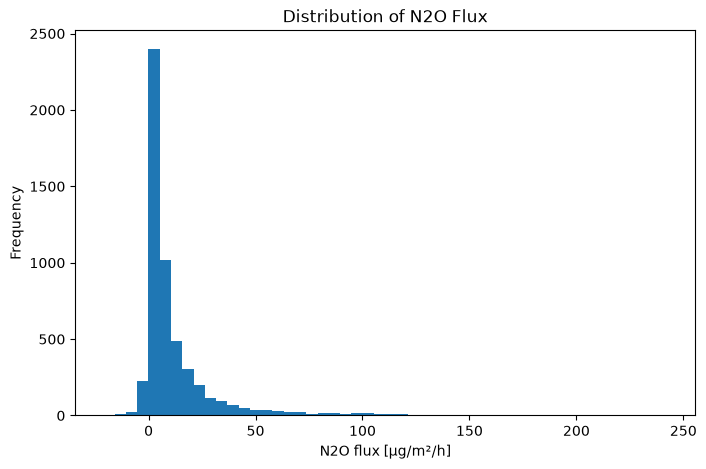

In [45]:
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COLUMN].dropna(), bins=50)
plt.xlabel("N2O flux [µg/m²/h]")
plt.ylabel("Frequency")
plt.title("Distribution of N2O Flux")
plt.show()

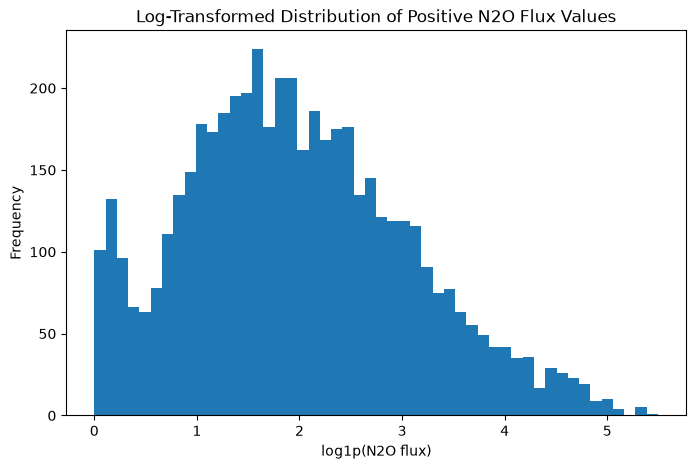

In [46]:
positive_target = df.loc[df[TARGET_COLUMN] > 0, TARGET_COLUMN]

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(positive_target), bins=50)
plt.xlabel("log1p(N2O flux)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Positive N2O Flux Values")
plt.show()

## 8. Numerical Feature Analysis

Explore the distribution of numerical variables using descriptive statistics and visualizations.

In [48]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

numeric_summary = df[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
Latitude,5280.0,-1.228231,3.703325,-17.706000,-2.139900,-1.260000,0.321900,6.054500
Longitude,5280.0,31.331031,10.765475,-0.381800,32.692700,35.380000,36.720000,38.226900
Fert N [kg/ha] (Recorded at time of application),5280.0,38.504735,46.788347,0.000000,0.000000,45.000000,50.000000,200.000000
TTT day m [°C] (ERA5 reanalyses),5280.0,21.133681,3.171982,13.069766,18.666322,20.614597,23.190000,28.942652
TxTxTx day max [°C] (ERA5 reanalyses),5280.0,25.754478,3.514496,16.074131,22.958315,25.779030,28.127880,35.700000
TnTnTn day min [°C] (ERA5 reanalyses),5280.0,17.674016,3.438315,6.959682,15.252268,16.875000,19.555776,26.212832
Precip day total [mm/day] (ERA5 reanalyses),5280.0,1.489663,4.270444,0.000000,0.001318,0.130284,1.126393,69.000000
"Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)",5280.0,0.315828,0.106214,0.078000,0.225582,0.328086,0.401567,0.507654
Soil moisture [m**3/m**3] (ERA5 reanalyses),5280.0,0.310683,0.105178,0.078000,0.225204,0.316613,0.398310,0.506686
Soil moisture [m**3/m**3] (ERA5 reanalyses).1,5280.0,0.294414,0.098814,0.066000,0.219140,0.300809,0.370087,0.510832


## 9. Categorical Feature Analysis

Analyze categorical variables such as land use and other classifications.

In [49]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print(categorical_columns)

for column in categorical_columns:
    print("=" * 80)
    print(column)
    print(df[column].value_counts(dropna=False).head(20))

['Event', 'Date/Time', 'Land use']
Event
Event
20SL-Maz         1695
24TO-ELD          483
25RG-SOR4D        396
24RD-Yang         301
15JH-Tumbi        288
19JZ-Mbeya        220
15JH-Yala         212
19JZ-Iringa       212
22MB-Yoko         127
14JH-Maseno       114
22MB-Kahuzi        98
17AG-KILO-FLM      95
17AG-KILO-FOC      90
23ML-MACH          90
23ML-SID           82
20SW-B-Mak         62
20SW-Taita         61
20SW-LUMO          60
20SW-C-Mak         57
25-SOR4D_FP        53
Name: count, dtype: int64
Date/Time
Date/Time
2019-03-02    22
2018-01-11    22
2019-08-08    21
2019-05-08    21
2019-05-04    21
2019-05-02    21
2019-04-11    21
2019-07-04    21
2019-07-10    21
2019-07-06    21
2019-01-11    21
2019-04-01    21
2019-02-12    21
2019-02-09    21
2019-06-04    21
2019-05-12    21
2019-04-04    21
2019-02-04    21
2019-04-02    20
2019-08-06    20
Name: count, dtype: int64
Land use
Land use
Cropland     3574
Forest       1481
Grassland     225
Name: count, dtype: int64


In [ ]:
display(df["Land use"].value_counts(dropna=False))


land_use_counts = df["Land use"].value_counts(dropna=False)

print(f'land_use_counts: {land_use_counts}')
plt.figure(figsize=(8, 5))
plt.bar(land_use_counts.index.astype(str), land_use_counts.values)
plt.xlabel("Land use")
plt.ylabel("Number of observations")
plt.title("Observations by Land Use")
plt.xticks(rotation=45, ha="right")
plt.show()

Land use
Cropland     3574
Forest       1481
Grassland     225
Name: count, dtype: int64

Event
20SL-Maz          1695
24TO-ELD           483
25RG-SOR4D         396
24RD-Yang          301
15JH-Tumbi         288
19JZ-Mbeya         220
15JH-Yala          212
19JZ-Iringa        212
22MB-Yoko          127
14JH-Maseno        114
22MB-Kahuzi         98
17AG-KILO-FLM       95
17AG-KILO-FOC       90
23ML-MACH           90
23ML-SID            82
20SW-B-Mak          62
20SW-Taita          61
20SW-LUMO           60
20SW-C-Mak          57
25-SOR4D_FP         53
25CA-SOR4D_DAF      45
17AG-KILO-COF       43
18IW-KAP-FR         42
18IW-CHESP-FR       42
18IW-CHESP-TEA      42
18IW-CHESP-GL       42
22MB-Jardin         41
23ML-ALDEK          40
18IW-KAP-TEA        33
18IW-KAP-EUCH       33
23ML-EMB            31
23AS-DTC            25
23AS-UZF            25
Name: count, dtype: int64

Event
20SL-Maz          1695
24TO-ELD           483
25RG-SOR4D         396
24RD-Yang          301
15JH-Tumbi         288
19JZ-Mbeya         220
15JH-Yala          212
19JZ-Iringa        212
22MB-Yoko          127
14JH-Maseno        114
22MB-Kahuzi         98
17AG-KILO-FLM       95
17AG-KILO-FOC       90
23ML-MACH           90
23ML-SID            82
20SW-B-Mak          62
20SW-Taita          61
20SW-LUMO           60
20SW-C-Mak          57
25-SOR4D_FP         53
25CA-SOR4D_DAF      45
17AG-KILO-COF       43
18IW-KAP-FR         42
18IW-CHESP-FR       42
18IW-CHESP-TEA      42
18IW-CHESP-GL       42
22MB-Jardin         41
23ML-ALDEK          40
18IW-KAP-TEA        33
18IW-KAP-EUCH       33
23ML-EMB            31
23AS-DTC            25
23AS-UZF            25
Name: count, dtype: int64

event_counts: Event
20SL-Maz          1695
24TO-ELD           483
25RG-SOR4D         396
24RD-Yang          301
15JH-Tumbi         288
19JZ-Mbeya         220
15JH-Yala          212
19JZ-Iringa        212
22MB-Yoko          127
14JH-Maseno        114
22MB-Kahuzi         98
17AG-KILO-FLM       95
17AG-KILO-FOC       90
23ML-MACH           90
23ML-SID            82
20SW-B-Mak          62
20SW-Taita          61
20SW-LUMO           60
20SW-C-Mak          57
25-SOR4D_FP         53
25CA-SOR4D_DAF      45
17AG-KILO-COF       43
18IW-KAP-FR         42
18IW-CHESP-FR       42
18IW-CHESP-TEA      42
18IW-CHESP-GL       42
22MB-Jardin         41
23ML-ALDEK          40
18IW-KAP-TEA        33
18IW-KAP-EUCH       33
23ML-EMB            31
23AS-DTC            25
23AS-UZF            25
Name: count, dtype: int64


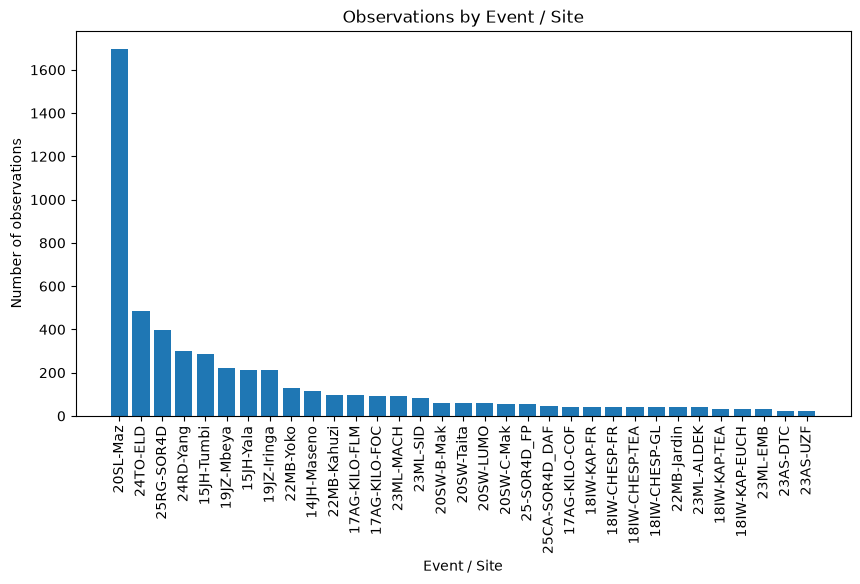

In [55]:
display(df["Event"].value_counts(dropna=False))
event_counts = df["Event"].value_counts()

print(f'event_counts: {event_counts}')

plt.figure(figsize=(10, 5))
plt.bar(event_counts.index.astype(str), event_counts.values)
plt.xlabel("Event / Site")
plt.ylabel("Number of observations")
plt.title("Observations by Event / Site")
plt.xticks(rotation=90)
plt.show()

In [51]:
print(f"Number of unique events/sites: {df['Event'].nunique()}")
print(f"Number of unique land-use classes: {df['Land use'].nunique()}")

Number of unique events/sites: 33
Number of unique land-use classes: 3


## 10. Temporal Analysis

Investigate temporal patterns by year, month, or season where applicable.

In [56]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"], errors="coerce")

print(f"Earliest date: {df['Date/Time'].min()}")
print(f"Latest date: {df['Date/Time'].max()}")
print(f"Number of unique dates: {df['Date/Time'].nunique():,}")

Earliest date: 2005-03-27 00:00:00
Latest date: 2025-07-12 00:00:00
Number of unique dates: 1,447


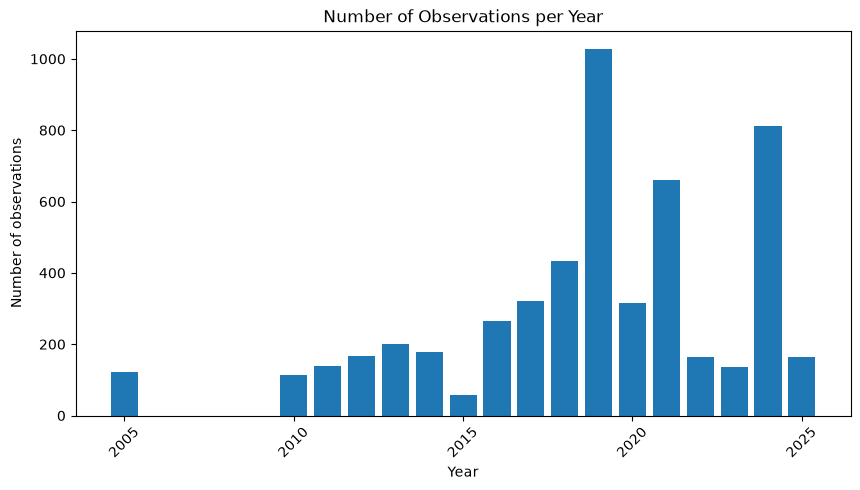

In [57]:
df["year"] = df["Date/Time"].dt.year
df["month"] = df["Date/Time"].dt.month
df["day_of_year"] = df["Date/Time"].dt.dayofyear

year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Number of Observations per Year")
plt.xticks(rotation=45)
plt.show()

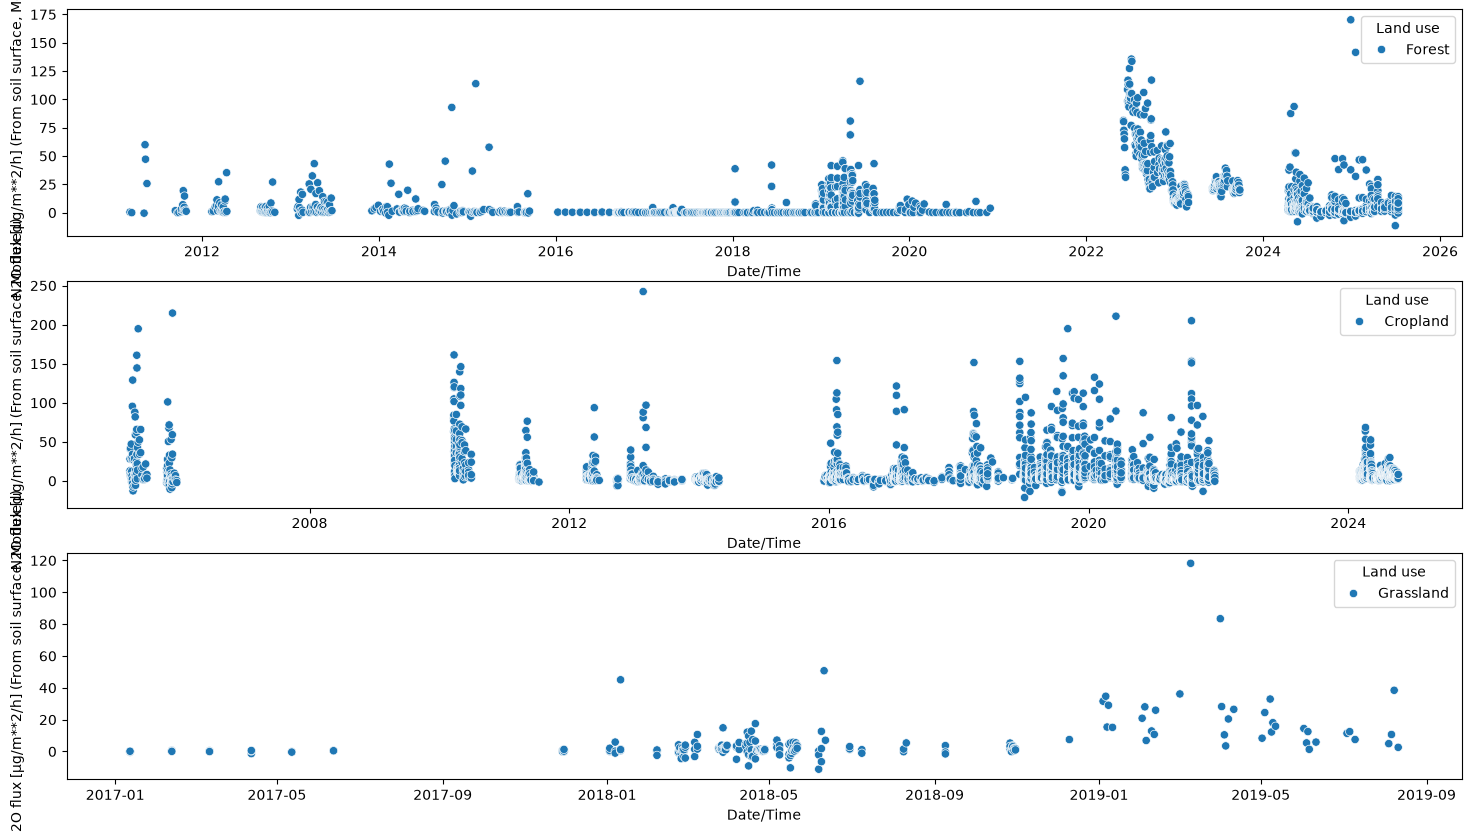

In [58]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 10))  # type: ignore
land_use_categories = df["Land use"].unique()
for ax, land_use in zip(axes.flatten(), land_use_categories):
    mask = df["Land use"] == land_use
    sns.scatterplot(
        data=df.loc[mask, :],
        x="Date/Time",
        y="N2O flux [µg/m**2/h] (From soil surface, Modeled)",
        hue="Land use",
        ax=ax,
    )

## 11. Spatial Analysis

Explore the geographical distribution of observations using latitude and longitude.

## 12. Outlier Analysis

Identify potential outliers and evaluate whether they represent measurement errors or meaningful observations.

## 13. Correlation Analysis

Compute and visualize correlations between numerical features.

In [59]:
correlation_with_target = (
    df[numeric_columns]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .sort_values(ascending=False)
)

correlation_with_target


N2O flux [µg/m**2/h] (From soil surface, Modeled)                1.000000
Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05))    0.110364
Cloud cov [%] (ERA5 reanalyses)                                  0.105158
TnTnTn day min [°C] (ERA5 reanalyses)                            0.090320
Latitude                                                         0.077809
Fert N [kg/ha] (Recorded at time of application)                 0.058045
Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)     0.049978
PPPP day m [hPa] (ERA5 reanalyses)                               0.040859
Soil moisture [m**3/m**3] (ERA5 reanalyses)                      0.039032
T soil day m [°C] (ERA5 reanalyses).2                            0.035421
TTT day m [°C] (ERA5 reanalyses)                                 0.026191
T soil day m [°C] (ERA5 reanalyses).1                            0.024521
Soil moisture [m**3/m**3] (ERA5 reanalyses).1                    0.023540
T soil day m [°C] (ERA5 reanalyses)   

<Axes: >

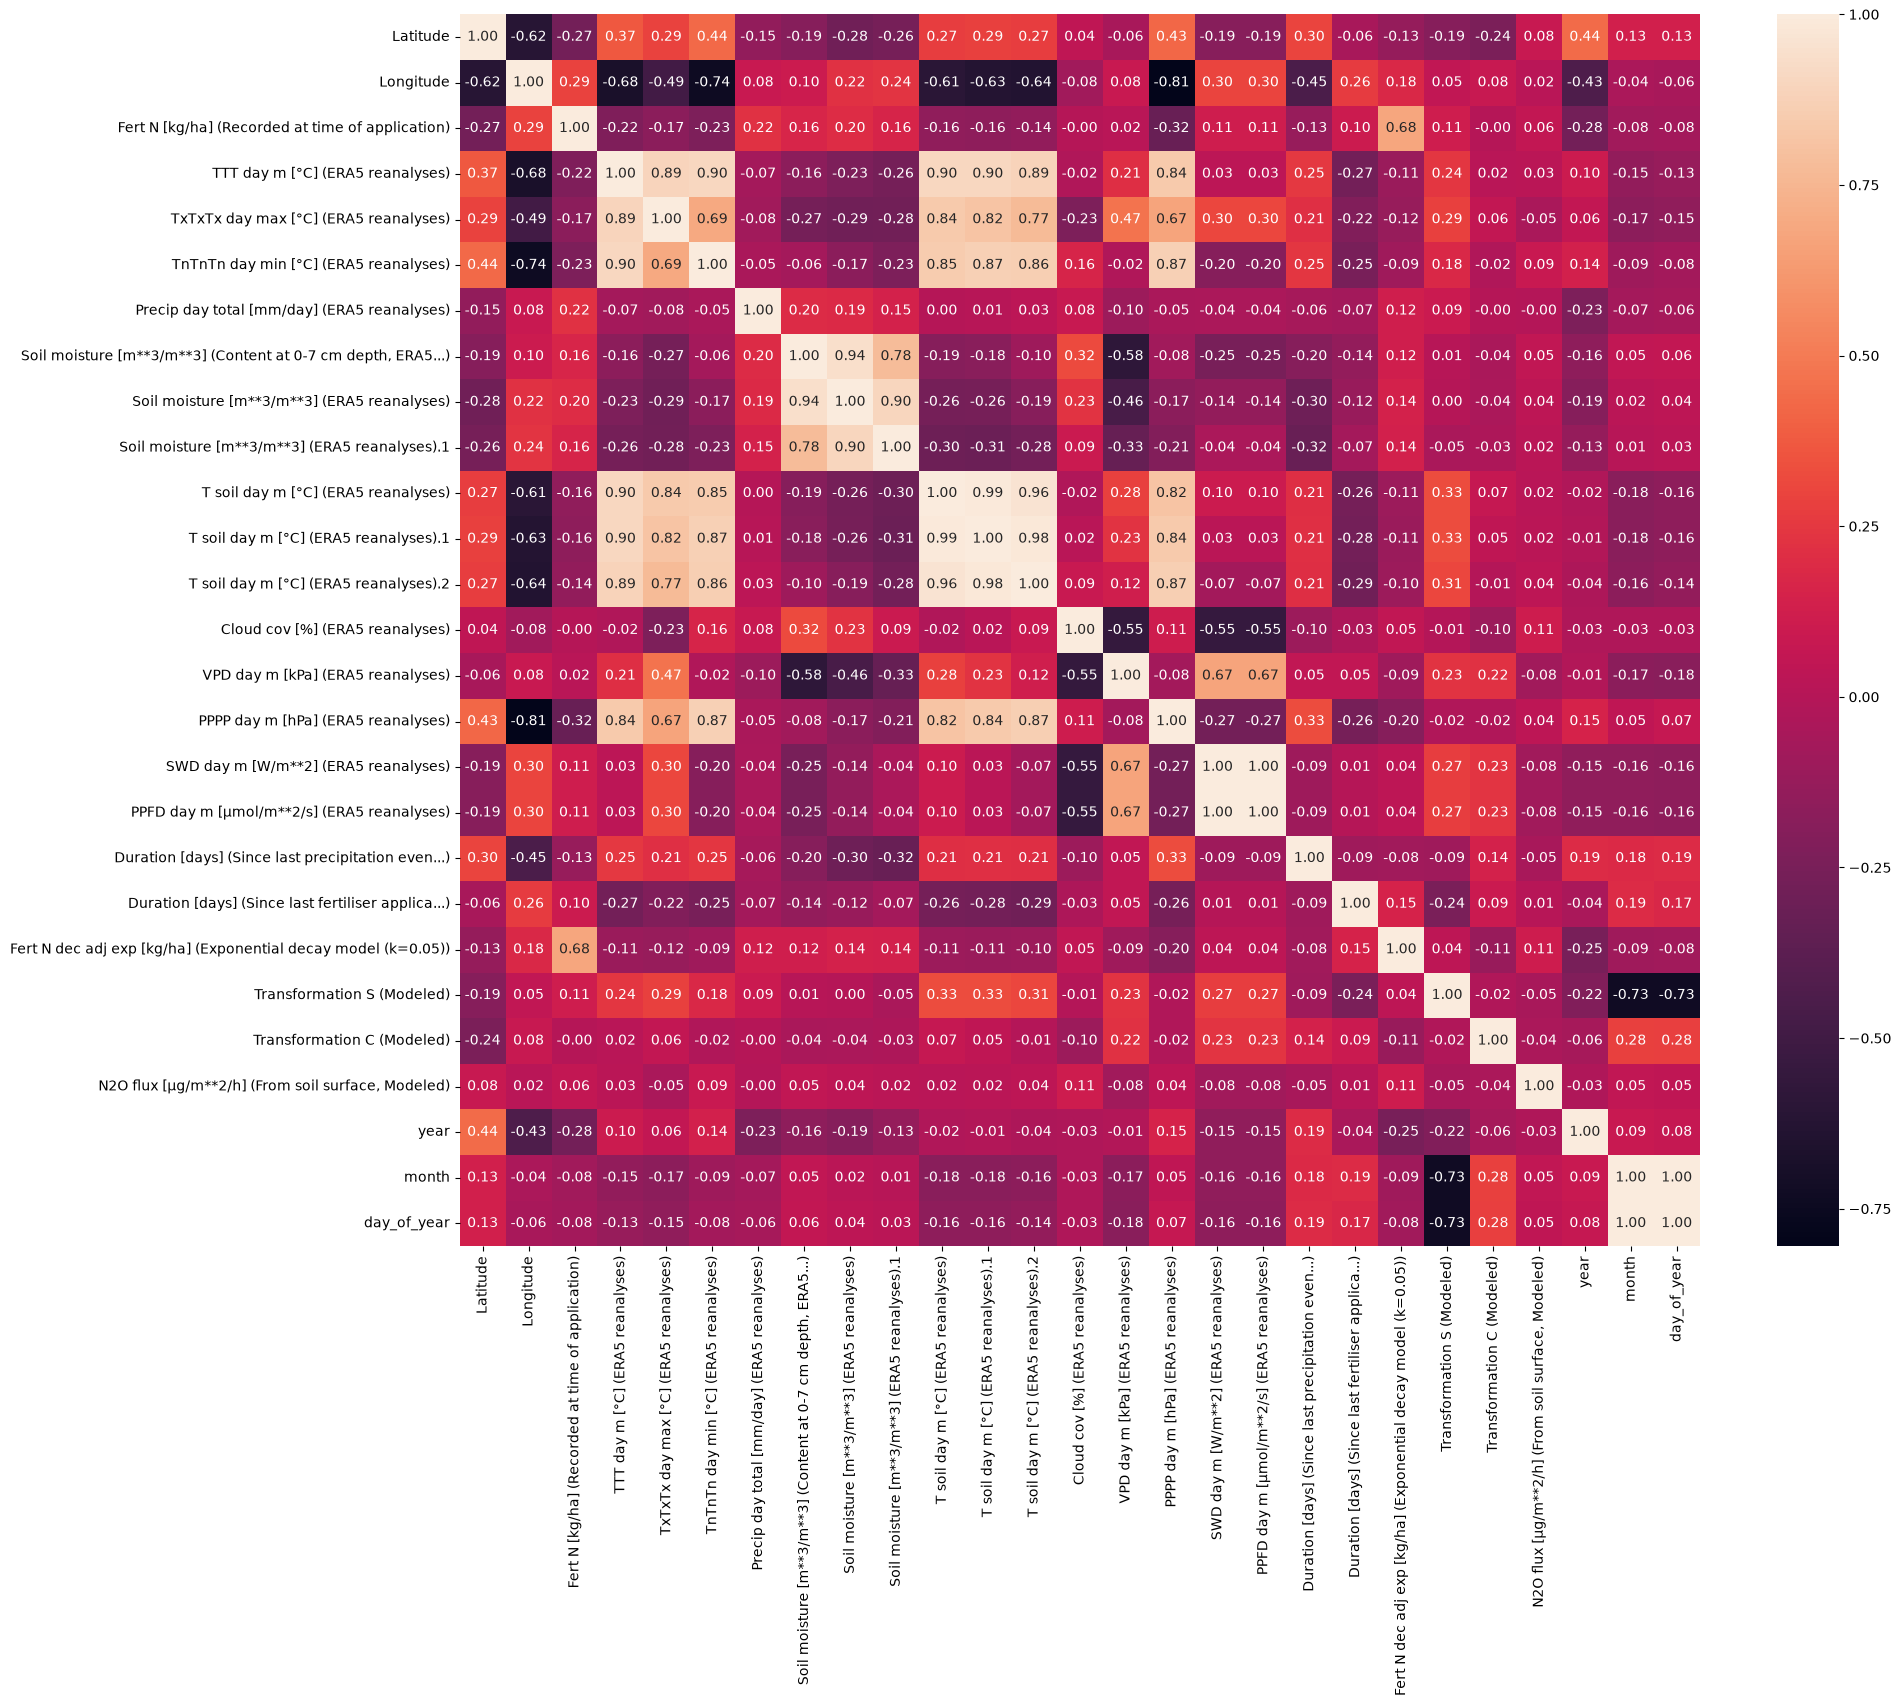

In [60]:

corr_matrix = df.loc[:,df.select_dtypes(include= [np.number]).columns].corr()

plt.figure(figsize = (20, 16))
sns.heatmap(corr_matrix, annot= True, linewidths=0, fmt= '.2f')

## 14. Feature Relationships

Investigate relationships between important predictors and the target variable.

## 15. Land Use Comparison

Compare feature distributions and target values across different land use classes.

In [61]:
n2o_by_land_use = (
    df.groupby("Land use")[TARGET_COLUMN]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values(by="median", ascending=False)
)

n2o_by_land_use

,count,mean,median,std,min,max
Land use,,,,,,
Cropland,3574,11.884864,5.508281,20.859414,-21.149615,242.346036
Forest,1481,13.645505,4.712477,21.551667,-11.501391,170.241240
Grassland,225,5.243767,1.470000,12.700628,-11.130000,118.179897


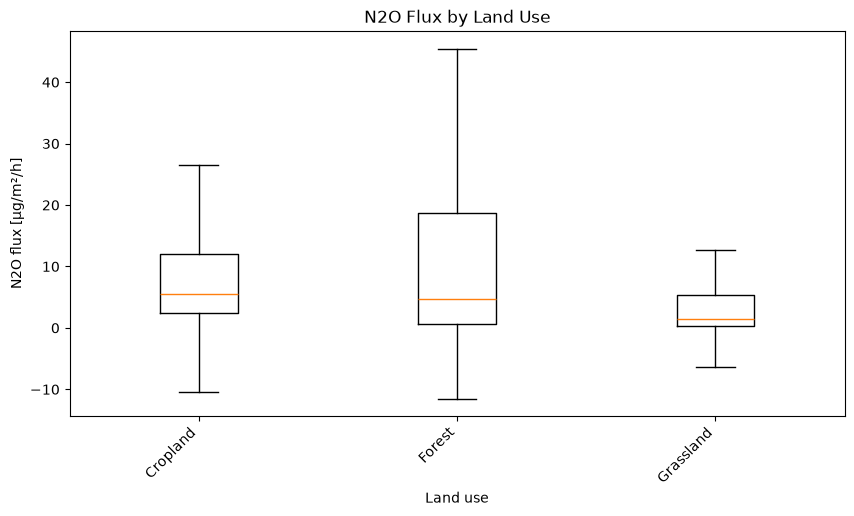

In [62]:
land_use_order = (
    df.groupby("Land use")[TARGET_COLUMN]
    .median()
    .sort_values(ascending=False)
    .index
)

data_to_plot = [
    df.loc[df["Land use"] == land_use, TARGET_COLUMN].dropna()
    for land_use in land_use_order
]

plt.figure(figsize=(10, 5))
plt.boxplot(data_to_plot, tick_labels=list(land_use_order), showfliers=False)
plt.xlabel("Land use")
plt.ylabel("N2O flux [µg/m²/h]")
plt.title("N2O Flux by Land Use")
plt.xticks(rotation=45, ha="right")
plt.show()

## 16. Feature Engineering Ideas

Document ideas for feature transformations, derived variables, and interaction terms.

## 17. Key Findings

Summarize the most important observations discovered during the EDA.

## 18. Next Steps

List planned preprocessing, feature engineering, and modeling tasks based on the EDA findings.